In [3]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.linalg import expm
from quantumScarFunctions import *
from quantumScarsPlotting import *

tau_r = 9.9083


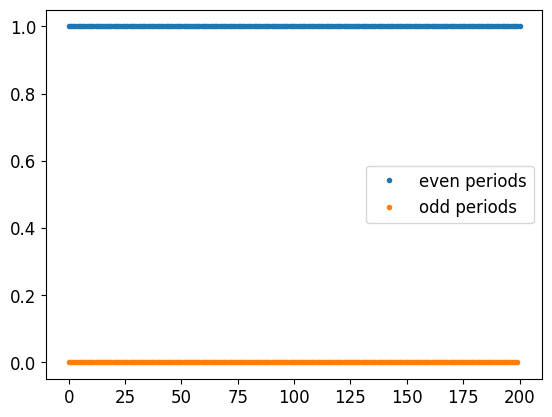

In [5]:
def kicked_scar(N, theta, tau, n_periods, ohms=1.0):
    H0, _, _, psi0, basisList = get_scar_ham(N, ohms=ohms, diagonalize=False)
    H1, _ = get_scar_H1_no_z2(N, basisList)          # sum_i sigma^z_i
    I_diag = get_scar_H1(N, basisList)[0].diag() / N  # imbalance operator

    kick = np.exp(-1j * (theta / 2) * H1.diag())      # theta/2 because H1 = 2*Nop - N
    U_tau = expm(-1j * tau * H0.full())

    z2 = psi0.full().ravel().astype(complex)
    psi = z2.copy()
    fid = np.empty(n_periods + 1)
    imb = np.empty(n_periods + 1)
    fid[0], imb[0] = 1.0, np.real(np.vdot(psi, I_diag * psi))

    for n in range(1, n_periods + 1):
        psi = kick * (U_tau @ psi)                    # evolve first, then kick
        fid[n] = abs(np.vdot(z2, psi)) ** 2
        imb[n] = np.real(np.vdot(psi, I_diag * psi))

    return fid, imb

N = 12
H0, w, v, psi0, _ = get_scar_ham(N)
amp = np.array([s.overlap(psi0) for s in v])
ts = np.linspace(2, 15, 20000)
f = np.abs((np.abs(amp)**2) @ np.exp(-1j * np.outer(w, ts)))**2
tau_r = ts[np.argmax(f)]
print(f"tau_r = {tau_r:.4f}")

fid, imb = kicked_scar(N=N, theta=np.pi, tau=0.993*tau_r/2, n_periods=400)

plt.plot(fid[0::2], '.', label='even periods')
plt.plot(fid[1::2], '.', label='odd periods')
plt.legend()
plt.show()

tau_r = 9.9083


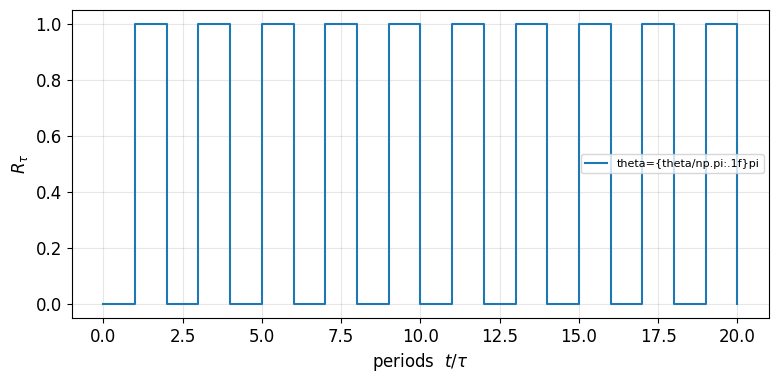

In [6]:
N = 8

def get_tau_r(N):
    H0, w, v, psi0, _ = get_scar_ham(N)
    amp = np.array([s.overlap(psi0) for s in v])
    ts = np.linspace(2, 15, 20000)
    f = np.abs((np.abs(amp)**2) @ np.exp(-1j * np.outer(w, ts)))**2
    return ts[np.argmax(f)]

def kicked_rtau(N, theta, tau, n_periods, ham_disorder=[0, 0, 0], N_dis=None, fixed_seed=False):
    H0, _, _, psi0, basisList = get_scar_ham(N, diagonalize=False)
    H0, evals, evecs = get_dis_scar_ham(H0, N, basisList,
                                        N_dis=N_dis,
                                        ham_disorder=ham_disorder,
                                        fixed_seed=fixed_seed)
    H1, _ = get_scar_H1_no_z2(N, basisList)
    Nvec = (H1.diag() + N) / 2
    bandwidth = evals[-1] - evals[0]

    H0f   = H0.full()
    kick  = np.exp(-1j * theta * Nvec)
    U_tau = expm(-1j * tau * H0f)

    psi = evecs[0].full().ravel().astype(complex)

    E = np.empty(2 * n_periods + 1)
    E[0] = np.real(np.vdot(psi, H0f @ psi))
    for n in range(n_periods):
        psi = U_tau @ psi                              # free evolution
        E[2*n + 1] = np.real(np.vdot(psi, H0f @ psi))  # just before the kick
        psi = kick * psi                               # kick
        E[2*n + 2] = np.real(np.vdot(psi, H0f @ psi))  # just after the kick

    times = np.repeat(np.arange(n_periods + 1) * tau, 2)[1:]
    return times, (E - E[0]) / bandwidth

tau_r = get_tau_r(N)
tau = 1.0#tau_r / 2
print(f"tau_r = {tau_r:.4f}")

plt.figure(figsize=(9, 4))
for theta in [np.pi]: #, 1.05*np.pi, 1.1*np.pi
    t, R = kicked_rtau(N, theta, tau, 20,
                       ham_disorder=[0.0, 0.0, 0.0], fixed_seed=True)
    plt.plot(t/tau, R, label="theta={theta/np.pi:.1f}pi")
    plt.xlabel("periods  $t/\\tau$")
    plt.ylabel("$R_\\tau$")
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
    plt.show()

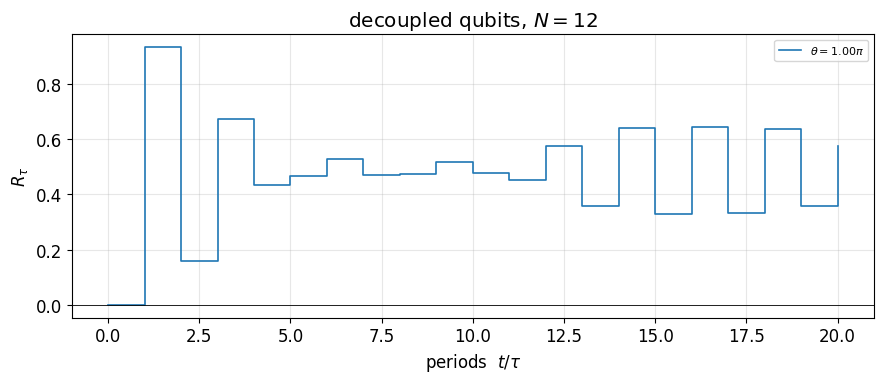

In [65]:
def kicked_qubits_rtau(N, theta, tau, n_periods, wm=1.0, ham_disorder=[0, 0, 0],
                       N_dis=None, fixed_seed=False, ds_dis=0.0,
                       sigz_ham=False, init="ground"):

    qH0, qH1, _ = get_qubit_ham(N, wm=wm, ham_disorder=ham_disorder, N_dis=N_dis,
                                fixed_seed=fixed_seed, ds_dis=ds_dis,
                                sigz_ham=sigz_ham)
    H0s = [h.full() for h in qH0]
    H1s = [h.full() for h in qH1]

    U_tau = [expm(-1j * tau * H) for H in H0s]
    kicks = [expm(-1j * (theta / 2.0) * H) for H in H1s]   # theta/2 matches your PXP convention

    psis = []
    for H in H0s:
        if init == "ground":
            psis.append(np.linalg.eigh(H)[1][:, 0].astype(complex))
        elif init == "up":
            psis.append(np.array([1.0, 0.0], dtype=complex))
        else:
            raise ValueError(init)

    bandwidth = sum(np.ptp(np.linalg.eigvalsh(H)) for H in H0s)
    energy = lambda ps: sum(np.real(np.vdot(p, H @ p)) for p, H in zip(ps, H0s))

    E = np.empty(2 * n_periods + 1)
    E[0] = energy(psis)
    for n in range(n_periods):
        psis = [U @ p for U, p in zip(U_tau, psis)]      # free evolution
        E[2*n + 1] = energy(psis)                        # just before the kick
        psis = [K @ p for K, p in zip(kicks, psis)]      # kick
        E[2*n + 2] = energy(psis)                        # just after the kick

    times = np.repeat(np.arange(n_periods + 1) * tau, 2)[1:]
    return times, (E - E[0]) / bandwidth

N, tau, n_periods = 12, 1.5, 20

plt.figure(figsize=(9, 4))
for theta in [np.pi]: #, 1.1*np.pi, 1.5*np.pi
    t, R = kicked_qubits_rtau(N, theta, tau, n_periods,
                              ham_disorder=[0.3, 1.0, 1.0], fixed_seed=False)
    plt.plot(t/tau, R, lw=1.2, label=f"$\\theta = {theta/np.pi:.2f}\\pi$")

plt.axhline(0, color='k', lw=0.6)
plt.xlabel("periods  $t/\\tau$")
plt.ylabel("$R_\\tau$")
plt.title(f"decoupled qubits, $N={N}$")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()